In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to sys.path")

Project root added to sys.path


In [2]:
import torch
import torch.nn 
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

from clients.federated_training import federated_training
from utils.data_partition import dirichlet_partition


torch.manual_seed(42)
np.random.seed(42)

In [3]:
import torchaudio
import torchaudio.transforms as T
import torch
import torch.nn.functional as F
import os

# MFCC Config
mfcc_config = {
    "sample_rate": 16000,
    "n_mfcc": 40,
    "n_fft": 1024,
    "hop_length": 512
}

# Define MFCC transform
mfcc_transform = T.MFCC(
    sample_rate=mfcc_config["sample_rate"],
    n_mfcc=mfcc_config["n_mfcc"],
    melkwargs={
        "n_fft": mfcc_config["n_fft"],
        "hop_length": mfcc_config["hop_length"],
        "n_mels": 64
    }
)

# Path to download the dataset
data_path = './data'

# Define a subclass to access train/valid/test split if needed
class SubsetSC(torchaudio.datasets.SPEECHCOMMANDS):
    def __init__(self, subset: str = None):
        super().__init__(data_path, download=True)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath) as f:
                return [os.path.join(self._path, line.strip()) for line in f]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = load_list("validation_list.txt") + load_list("testing_list.txt")
            excludes = set(excludes)
            self._walker = [w for w in self._walker if w not in excludes]

# Custom wrapper that applies MFCC, pads/truncates, and supports .targets
class MFCCSpeechCommands(torch.utils.data.Dataset):
    def __init__(self, subset: str = "training", transform=None, label_to_index=None, max_len: int = 100):
        self.dataset = SubsetSC(subset)
        self.transform = transform
        self.max_len = max_len

        # Build consistent label mapping
        if label_to_index is None:
            all_labels = sorted(set(label for _, _, label, *_ in self.dataset))
            self.label_to_index = {label: i for i, label in enumerate(all_labels)}
        else:
            self.label_to_index = label_to_index

        self.targets = [self.label_to_index[label] for _, _, label, *_ in self.dataset]

    def __getitem__(self, index):
        waveform, sample_rate, label, *_ = self.dataset[index]
        features = self.transform(waveform) if self.transform else waveform  # shape: [1, 40, T]

        # Pad or truncate to fixed time length
        if features.shape[-1] < self.max_len:
            pad_amount = self.max_len - features.shape[-1]
            features = F.pad(features, (0, pad_amount))
        elif features.shape[-1] > self.max_len:
            features = features[..., :self.max_len]

        return features, self.label_to_index[label]

    def __len__(self):
        return len(self.dataset)

# Create label-to-index mapping once
base_dataset = SubsetSC("training")
unique_labels = sorted(set(label for _, _, label, *_ in base_dataset))
label_to_index = {label: i for i, label in enumerate(unique_labels)}

# Wrap datasets with MFCC transform and shared label mapping
trainset = MFCCSpeechCommands("training", transform=mfcc_transform, label_to_index=label_to_index)
val_set  = MFCCSpeechCommands("validation", transform=mfcc_transform, label_to_index=label_to_index)
testset  = MFCCSpeechCommands("testing", transform=mfcc_transform, label_to_index=label_to_index)

print(f"Train samples:     {len(trainset)}")
print(f"Validation samples:{len(val_set)}")
print(f"Test samples:      {len(testset)}")
print(f"Number of classes: {len(label_to_index)}")


Train samples:     105829
Validation samples:9981
Test samples:      11005
Number of classes: 35


In [4]:
num_clients = 5
partitions = {
    "noniid":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.01),
    "medium":   dirichlet_partition(trainset, num_clients=num_clients, alpha=0.5),
}


=== Partition Statistics for SC ===

NONIID Partition:
Total samples: 105829

Per-client distribution:
Client 0: 30969 samples (29.26%)
Client 1: 17705 samples (16.73%)
Client 2: 18854 samples (17.82%)
Client 3: 16015 samples (15.13%)
Client 4: 22286 samples (21.06%)

MEDIUM Partition:
Total samples: 105829

Per-client distribution:
Client 0: 18605 samples (17.58%)
Client 1: 17421 samples (16.46%)
Client 2: 21395 samples (20.22%)
Client 3: 26374 samples (24.92%)
Client 4: 22034 samples (20.82%)
[Debug] Number of classes: 35
[Debug] Number of clients: 5
[Debug] Processing client 0 with 30969 samples
[Debug] Client 0 has 30969 valid targets
[Debug] Client 0 class counts: [1.659e+03 1.000e+00 1.000e+00 2.026e+03 1.000e+00 1.000e+00 3.719e+03
 1.000e+00 1.000e+00 1.000e+00 1.000e+00 3.875e+03 1.000e+00 1.000e+00
 1.000e+00 1.000e+00 1.000e+00 1.000e+00 3.936e+03 1.000e+00 1.000e+00
 1.000e+00 1.000e+00 1.000e+00 2.017e+03 3.851e+03 3.867e+03 1.000e+00
 1.000e+00 3.876e+03 1.000e+00 1.000e

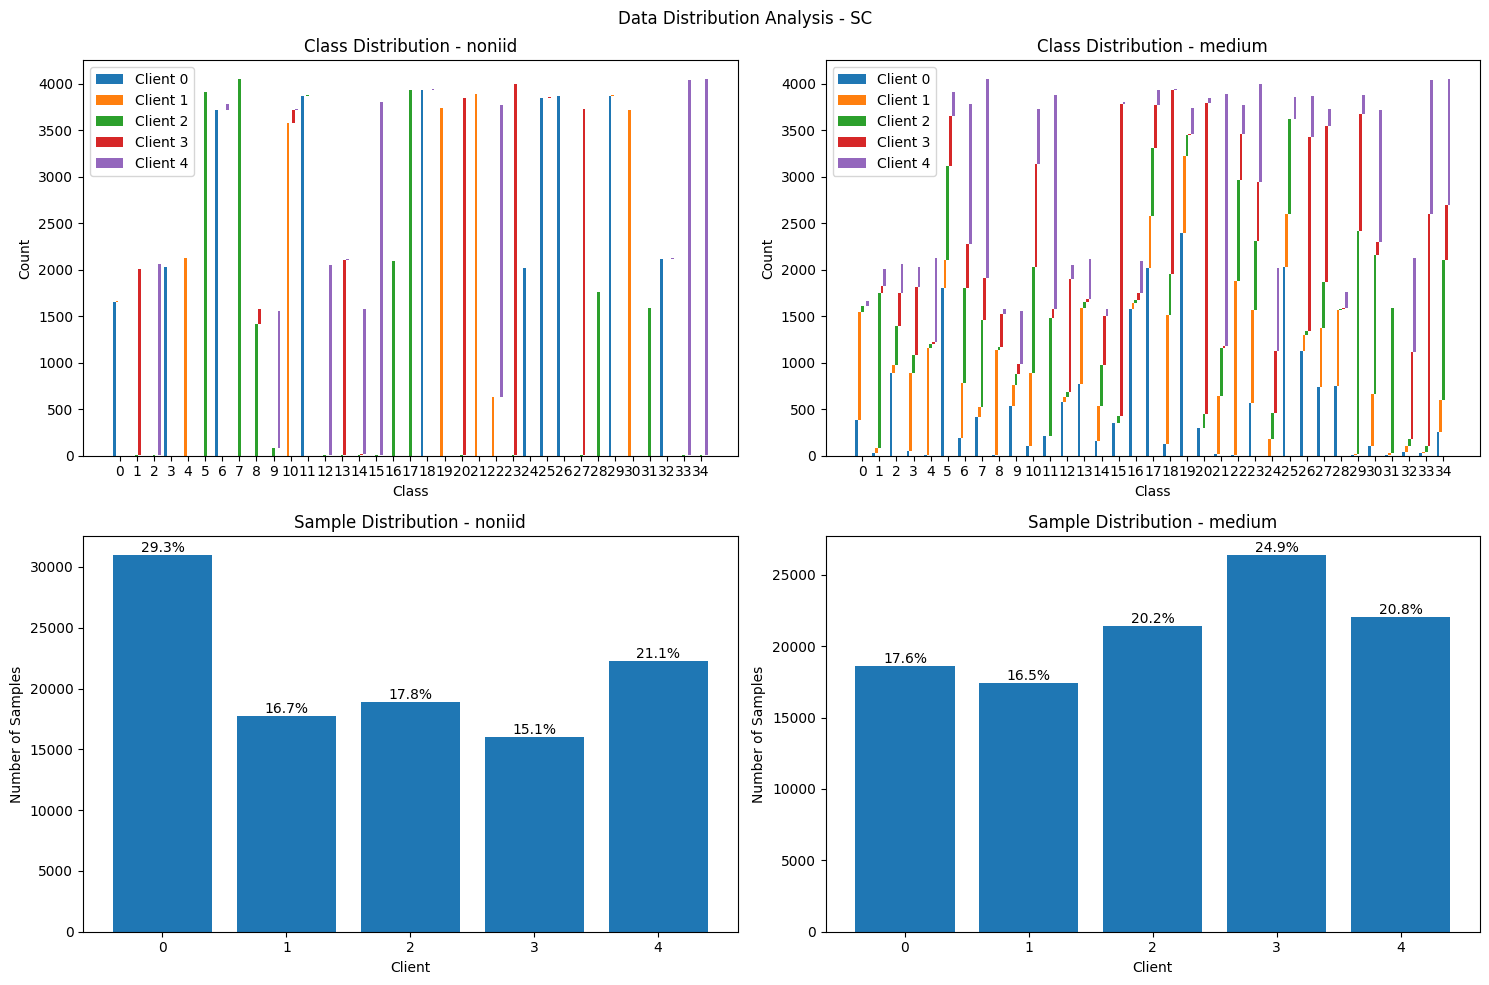

In [5]:
from utils.partitions_visualization import print_partition_stats, plot_data_distribution

# Print detailed statistics
print_partition_stats(partitions, "SC")

# Create comprehensive visualization
fig = plot_data_distribution(partitions, "SC")
plt.show()

In [6]:
from models.config import get_tinyprop_config
config = get_tinyprop_config("speechcommands")
print("\nModel Configuration:")
for key, value in config.items():
    print(f"{key}: {value}")

# Initialize model parameters
tinyprop_params = config["tinyprop_params"]
print("\nTinyProp Parameters:")
print(f"S_min: {tinyprop_params.S_min}")
print(f"S_max: {tinyprop_params.S_max}")
print(f"zeta: {tinyprop_params.zeta}")
print(f"number_of_layers: {tinyprop_params.number_of_layers}")


Model Configuration:
tinyprop_params: <models.tinyProp.TinyPropParams object at 0x000001F377659910>
optimizer: {'type': 'sgd', 'lr': 0.001, 'weight_decay': 0.0001}
lr_scheduler: {'type': 'cosine', 'T_max': 50, 'eta_min': 1e-05, 'warmup_epochs': 3, 'warmup_start_lr': 1e-05}
gradient_clip: 1.0
batch_size: 32
num_epochs: 1
label_smoothing: 0.1
quantization: {'bits': 8, 'enabled': True}
mfcc_config: {'sample_rate': 16000, 'n_mfcc': 40, 'n_fft': 1024, 'hop_length': 512}

TinyProp Parameters:
S_min: 0.5
S_max: 0.95
zeta: 0.5
number_of_layers: 6


In [ ]:
from clients.aggregators import sparse_fedavg_aggregate
def train_and_analyze_partition(partition_name, client_datasets, tinyprop_params):
    print(f"\nTraining on partition: {partition_name.upper()}")
    
    # Run training
    model, accuracy_list, flops_list, mem_list, comm_list, sparsity_list, \
    avg_grad_norm_list, avg_phi_list, skipped_batches_list, \
    effective_compute_ratio_list, client_eval_history, compression_ratio_list, \
    quantization_errors, avg_scale_factors, history = federated_training(
        client_datasets=client_datasets,
        model_name='speechcommands',
        testset=testset,
        tinyprop_params=tinyprop_params,
        aggregator_fn=sparse_fedavg_aggregate,
        rounds=100,
        device="cuda" if torch.cuda.is_available() else "cpu",
        local_epochs=1,
        early_stopping_patience=None,
        early_stopping_delta=0.001,
        csv_log_path=f'results/speechcommands_5cl_{partition_name}.csv',
        initial_sparsity=tinyprop_params.S_min,
        target_sparsity=tinyprop_params.S_max,
        energy_budget=1000,
        quantization_bits=8,  # Add quantization bits parameter
        save_dir='results',  # Add save directory for logs
        save_interval=1  # Save metrics every round
    )
    
    # Store quantization metrics in history
    history['quantization_errors'] = quantization_errors
    history['avg_scale_factors'] = avg_scale_factors
    
    return model, history

# Update the config to include quantization parameters
config = get_tinyprop_config('speechcommands')
config['quantization_bits'] = 8  # Add quantization bits to config

partition_results = {}
for strategy_name, client_datasets in partitions.items():
    print(f"\nStarting training for {strategy_name.upper()} partition...")
    try:
        model, history = train_and_analyze_partition(strategy_name, client_datasets, tinyprop_params)
        partition_results[strategy_name] = {
            'model': model,
            'history': history,
            'quantization_metrics': {
                'errors': history['quantization_errors'],
                'scale_factors': history['avg_scale_factors']
            }
        }
        print(f"Completed training for {strategy_name.upper()}")
    except Exception as e:
        print(f"Error in {strategy_name.upper()}: {str(e)}")
        continue




Starting training for NONIID partition...

Training on partition: NONIID

Round 1/100
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000
[Debug] Round 0 loss threshold: 0.1000

[Client Debug] Starting training for 1 epochs with batch size 32
[Debug] Round 0 loss threshold: 0.1000

[Batch 5] Debug Info:
  - Loss: 3.5239
  - Loss Change: 0.0000
  - Relative Loss Change: 0.0000
  - Dynamic Threshold: 0.2000
  - Current phi_k: 0.4579
  - Current phi_max: 0.9900
  - Layer Sparsity: 0.5000
  - Skip Ratio: 0.2000
  - Current Skip Ratio: 0.2000
  - Should Skip: False
[Debug][Batch 5] Loss: 3.5411
[Debug][Batch 5] Loss Change: 0.0172
[Debug][Batch 5] Relative Loss Change: 0.0049
[Debug][Batch 5] Phi Update: -0.0005
[Debug][Batch 5] New phi_k: 0.4575
[Debug] phi_k_history: [0.2996348397477799, 0.37872369278395884, 0.37837261146422513, 0.4579260830831173, 0.4575353102972678]

[Batch 10] Debug